In [16]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [3]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [4]:
wind_en      = []
wind_vel     = []
rho_rec      = []
sf_ts        = []
ef_kin       = []
ef_high      = []
f_re         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re.append(float(line.split()[1]))
        
wind_en   = np.asarray(wind_en)
wind_vel  = np.asarray(wind_vel)
rho_rec   = np.asarray(rho_rec)
sf_ts     = np.asarray(sf_ts)
ef_kin    = np.asarray(ef_kin)
ef_high   = np.asarray(ef_high)
f_re      = np.asarray(f_re)

In [5]:
def pars(i, mstar):

    arr = np.vstack( (mstar, np.ones(len(mstar)) * wind_en[i] ) ).T#,\
                        # np.ones(len(mstar)) * wind_vel[i],\
                        # np.ones(len(mstar)) * rho_rec[i],\
                        # np.ones(len(mstar)) * sf_ts[i],\
                        # np.ones(len(mstar)) * ef_kin[i],\
                        # np.ones(len(mstar)) * ef_high[i],\
                        # np.ones(len(mstar)) * f_re[i])).T

    return arr

#### Load the MTNG

In [6]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

2025-11-25 00:39:57,653 bacco.sims : Initialising simulation Default
2025-11-25 00:39:57,655 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 00:39:57,659 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 00:39:57,726 bacco.sims : ...done in 0.0249 s


### Load the Zooms

In [7]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

In [8]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

loaded = []
for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


2025-11-25 00:39:59,159 bacco.sims : Initialising simulation Default
2025-11-25 00:39:59,160 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 00:39:59,178 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264


2025-11-25 00:39:59,676 bacco.sims : ...done in 0.0284 s
2025-11-25 00:39:59,677 bacco.sims : Initialising simulation Default
2025-11-25 00:39:59,678 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 00:39:59,683 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 00:40:00,393 bacco.sims : ...done in 0.00916 s
2025-11-25 00:40:00,394 bacco.sims : Initialising simulation Default
2025-11-25 00:40:00,394 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 00:40:00,402 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 00:40:00,423 bacco.sims : ...done in 0.012 s
2025-11-25 00:40:00,424 bacco.sims : Initialising simulation Default
2025-11-25 00:40:00,425 bacco.sims : try /cosmos_stora

In [9]:
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [10]:
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264)

2025-11-25 00:40:07,752 bacco.sims : Initialising simulation Default
2025-11-25 00:40:07,755 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 00:40:07,756 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 00:40:07,810 bacco.sims : ...done in 0.00672 s
2025-11-25 00:40:07,815 bacco.sims : Reading 98233510 items for GroupPos


2025-11-25 00:40:16,378 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-25 00:40:23,466 bacco.sims : Reading 142791 items for GroupPos
2025-11-25 00:40:23,850 bacco.sims : Reading 142791 items for Group_M_Mean200
2025-11-25 00:40:23,912 bacco.sims : Reading 98233510 items for Group_M_Mean200
2025-11-25 00:40:41,560 bacco.sims : Reading 76572 items for SubhaloVmax
2025-11-25 00:40:41,655 bacco.sims : Reading 142791 items for halo_firstsub
2025-11-25 00:40:41,717 bacco.sims : Reading 90246895 items for SubhaloVmax
2025-11-25 00:41:08,817 bacco.sims : Reading 98233510 items for halo_firstsub
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:852: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )
2025-11-25 00:41:33,833 bacco.sims : Initialising simulation Default
2025-11-25 00:41:33,836 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 00:41:33,851 bacco.sims : Loading /

In [11]:
m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

2025-11-25 00:57:58,751 bacco.sims : Reading 98233510 items for Group_M_Mean200
/tmp/ipykernel_163764/1581714549.py:1: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])


In [12]:
zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

In [71]:
Nbins = 8

zoom_fgas = {}

for i in range(len(name_list)):
    zoom_fgas[name_list[i]] = zoom_split[name_list[i]].halo_gas_frac(sel_mask=zoom_sel[name_list[i]], nbins=Nbins, draws=1)

Text(0, 0.5, 'SMF $[h^3 Mpc^{-3} dex^{-1}]$')

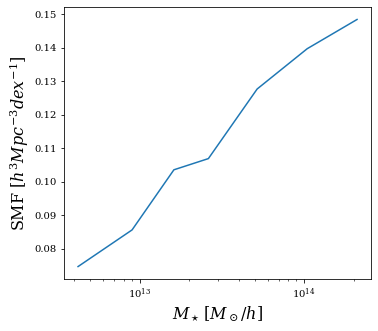

In [72]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('linear')

ax.plot(zoom_fgas['fiducial']['m500c'][0], zoom_fgas['fiducial']['f_gas'][0])

ax.set_xlabel(r"$M_\star\, [M_\odot/h]$", fontsize=16)
ax.set_ylabel(r"SMF $[h^3 Mpc^{-3} dex^{-1}]$", fontsize=16)

In [35]:
zoom_fgas['LH_0']['counts']

{0: array([9., 9., 2., 2., 2.])}

In [15]:
train_sel = random.sample(range(31), 20)
test_sel = list(set(range(31)) - set(train_sel))

In [375]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_smf[name_list[train_sel[0]]]['mstar'][0]) )
smf_global = np.log10(zoom_smf[name_list[train_sel[0]]]['smf'][0])

for i in range(len(train_sel)):
    mstar = np.log10(zoom_smf[name_list[train_sel[i]]]['mstar'][0])

    arr = pars(train_sel[i], mstar)

    pars_global = np.vstack((pars_global, arr))

    smf_global = np.hstack((smf_global, np.log10(zoom_smf[name_list[train_sel[i]]]['smf'][0])))

In [376]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(smf_global, dtype=torch.float)

### Build the GP Model

In [387]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-2))
likelihood.noise = torch.tensor(0.1**2)
model = ExactGPModel(train_x, train_y, likelihood)

In [388]:
# # We will use the simplest form of GP model, exact inference
# class SpectralMixtureGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
#         #self.covar_module.initialize_from_data(train_x, train_y)

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# # initialize likelihood and model
# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGPModel(train_x, train_y, likelihood)

#### Train it

In [389]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 400


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -torch.sum(mll(output, train_y))
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/400 - Loss: 1.397   noise: 0.010
Iter 2/400 - Loss: 1.361   noise: 0.010
Iter 3/400 - Loss: 1.325   noise: 0.010
Iter 4/400 - Loss: 1.289   noise: 0.010
Iter 5/400 - Loss: 1.253   noise: 0.010
Iter 6/400 - Loss: 1.217   noise: 0.010
Iter 7/400 - Loss: 1.182   noise: 0.010
Iter 8/400 - Loss: 1.146   noise: 0.010
Iter 9/400 - Loss: 1.112   noise: 0.010
Iter 10/400 - Loss: 1.077   noise: 0.010
Iter 11/400 - Loss: 1.043   noise: 0.010
Iter 12/400 - Loss: 1.010   noise: 0.010
Iter 13/400 - Loss: 0.977   noise: 0.010
Iter 14/400 - Loss: 0.946   noise: 0.010
Iter 15/400 - Loss: 0.915   noise: 0.010
Iter 16/400 - Loss: 0.884   noise: 0.010
Iter 17/400 - Loss: 0.855   noise: 0.010
Iter 18/400 - Loss: 0.827   noise: 0.010
Iter 19/400 - Loss: 0.799   noise: 0.010
Iter 20/400 - Loss: 0.773   noise: 0.010
Iter 21/400 - Loss: 0.747   noise: 0.010
Iter 22/400 - Loss: 0.723   noise: 0.010
Iter 23/400 - Loss: 0.699   noise: 0.010
Iter 24/400 - Loss: 0.677   noise: 0.010
Iter 25/400 - Loss: 0.655

In [382]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[1.7276, 2.3047]], grad_fn=<SoftplusBackward0>)
tensor(1.2571, grad_fn=<SoftplusBackward0>)
tensor([0.2459], grad_fn=<SqrtBackward0>)


In [301]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[1.7857, 0.6134]], grad_fn=<SoftplusBackward0>)
tensor(1.4368, grad_fn=<SoftplusBackward0>)
tensor([0.0912], grad_fn=<SqrtBackward0>)


In [294]:
print(model.covar_module.base_kernel.lengthscale)
print(model.covar_module.outputscale)
print(torch.sqrt(model.likelihood.noise_covar.noise))

tensor([[1.8499, 2.2105]], grad_fn=<SoftplusBackward0>)
tensor(1.2254, grad_fn=<SoftplusBackward0>)
tensor([0.2109], grad_fn=<SqrtBackward0>)


In [383]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# # Test points are regularly spaced along [0,1]
# # Make predictions by feeding model through likelihood
# with torch.no_grad(), gpytorch.settings.fast_pred_var():
#     #smf_test = model(mstar_test)
#     observed_pred1 = likelihood(model(torch.asarray(test_x1, dtype=torch.float)))

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

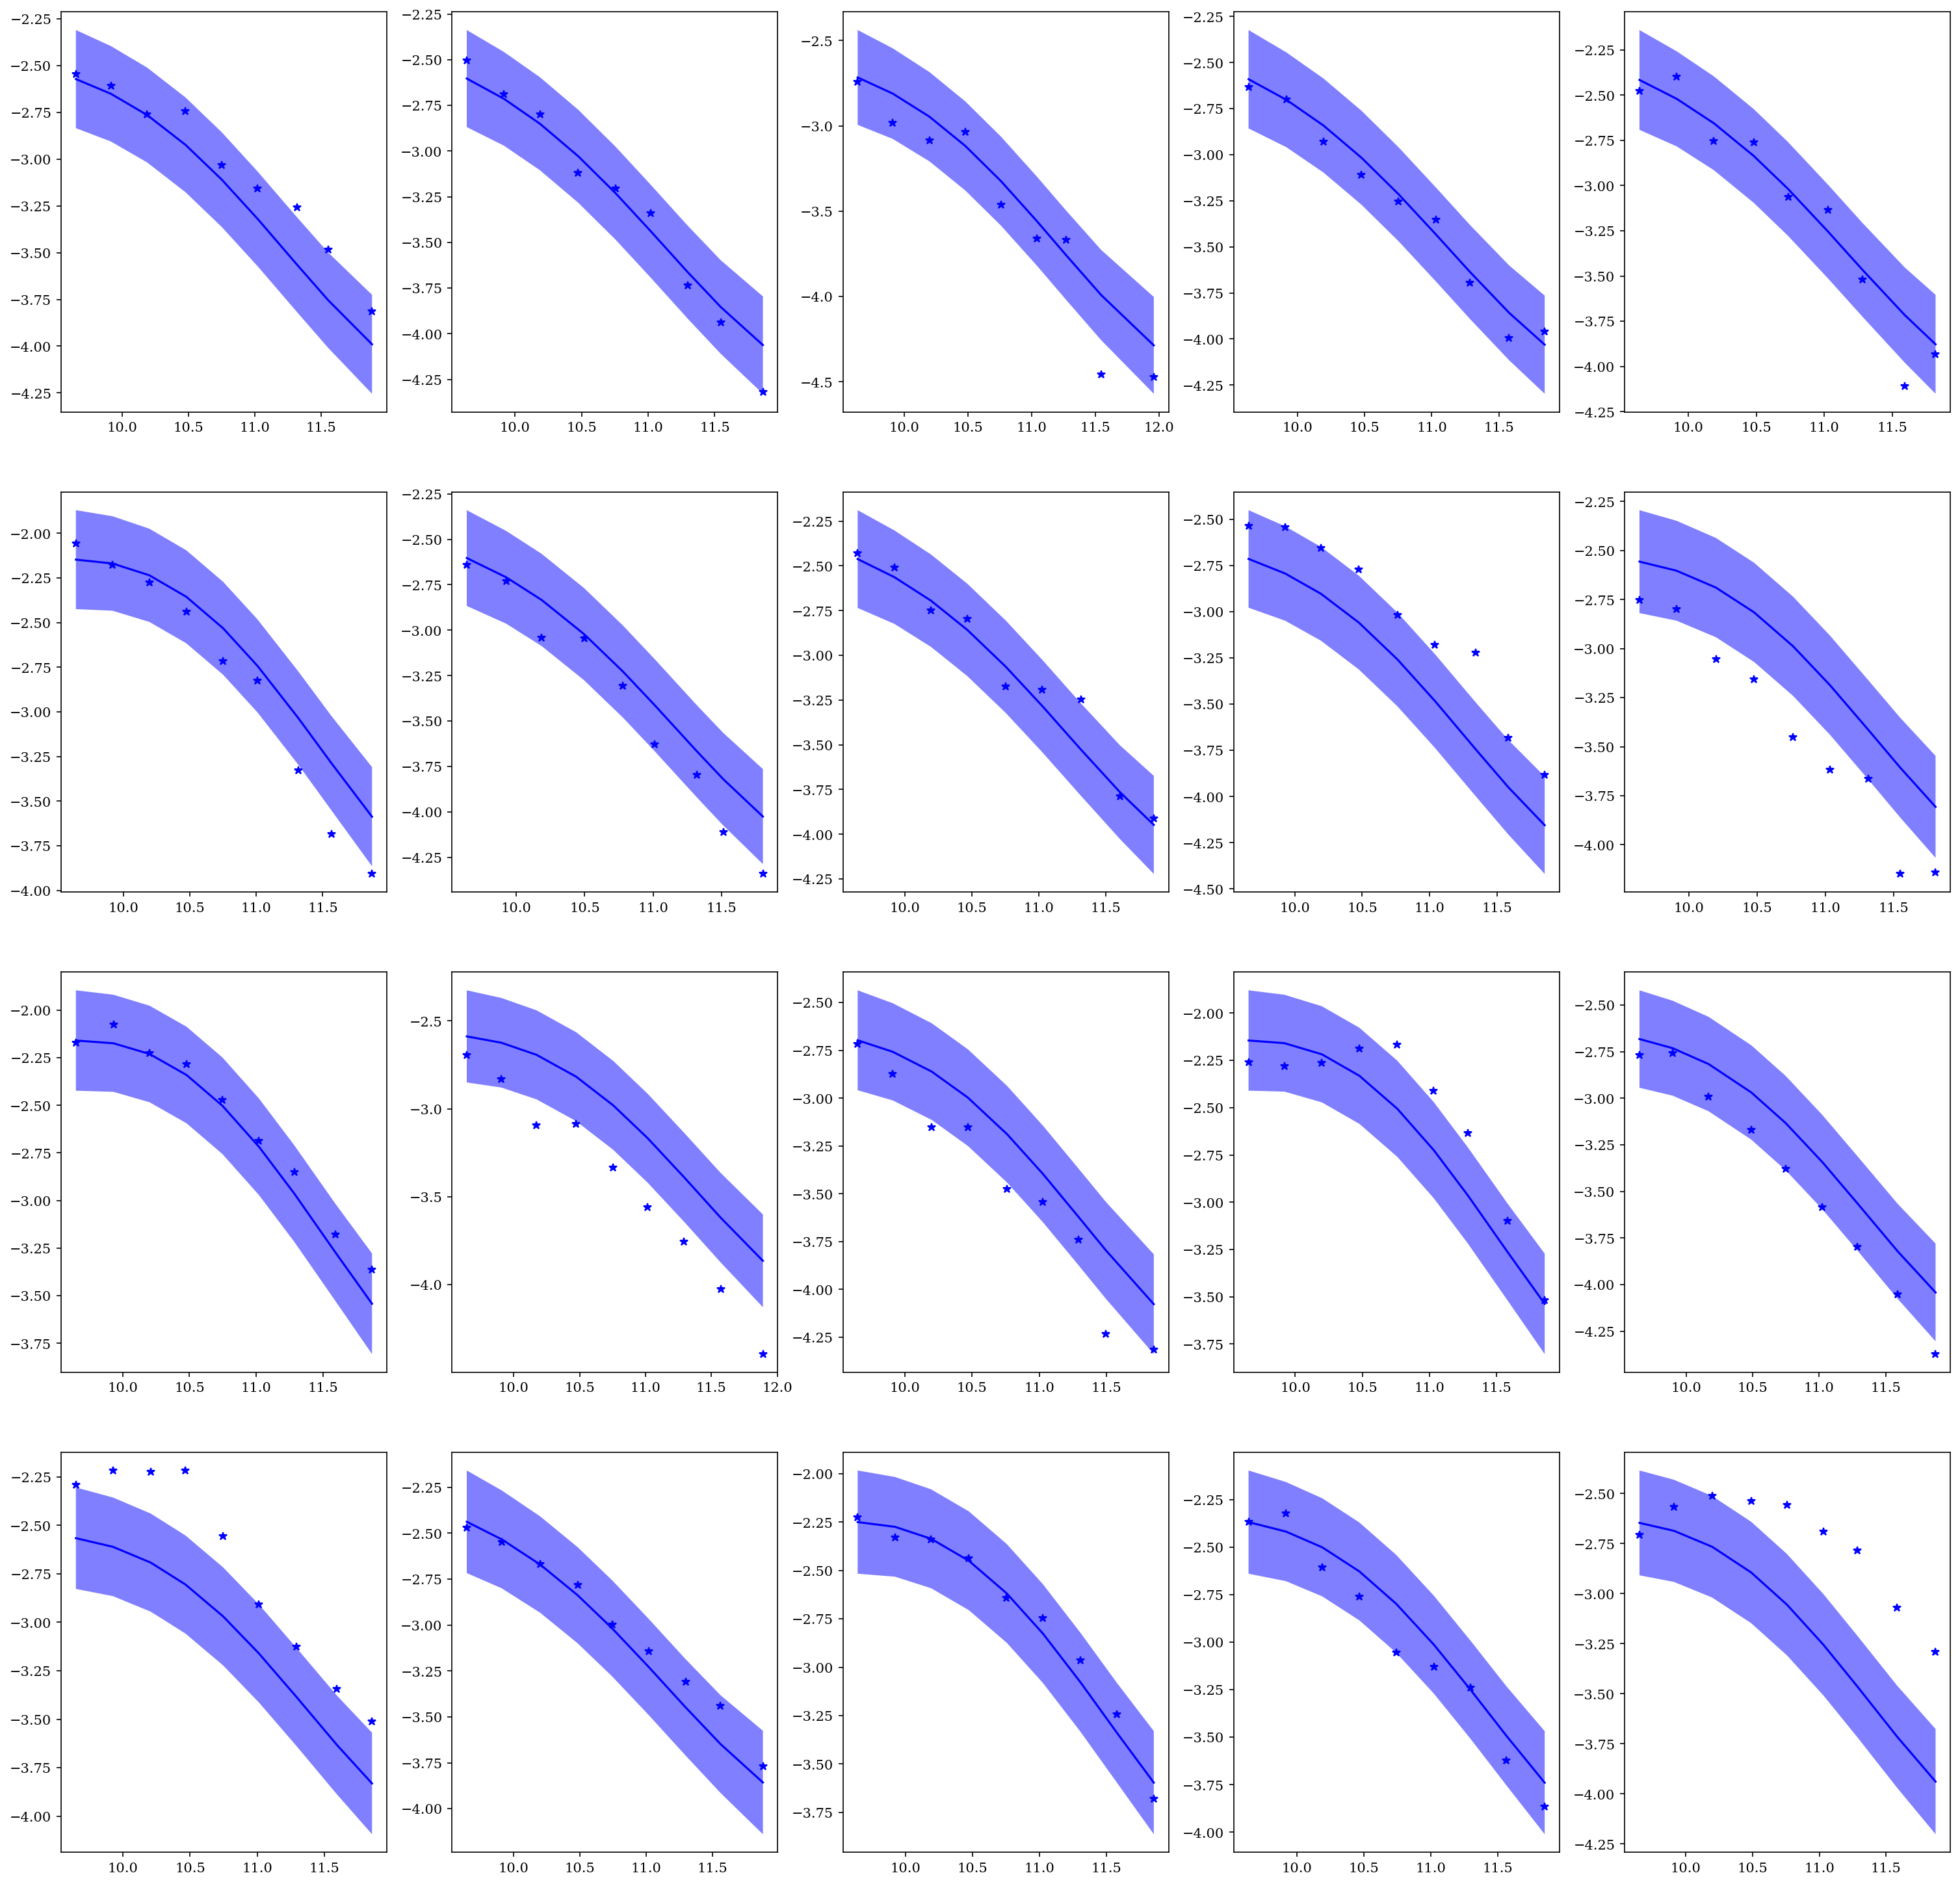

In [384]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(4, 5, figsize=(25, 25), dpi=150)

    for i in range(4):
        for j in range(5):
    
            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['smf'][0]), 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


In [368]:
test_sel

[[0, 1, 8, 12, 13, 14, 21, 22, 25, 29, 30]]

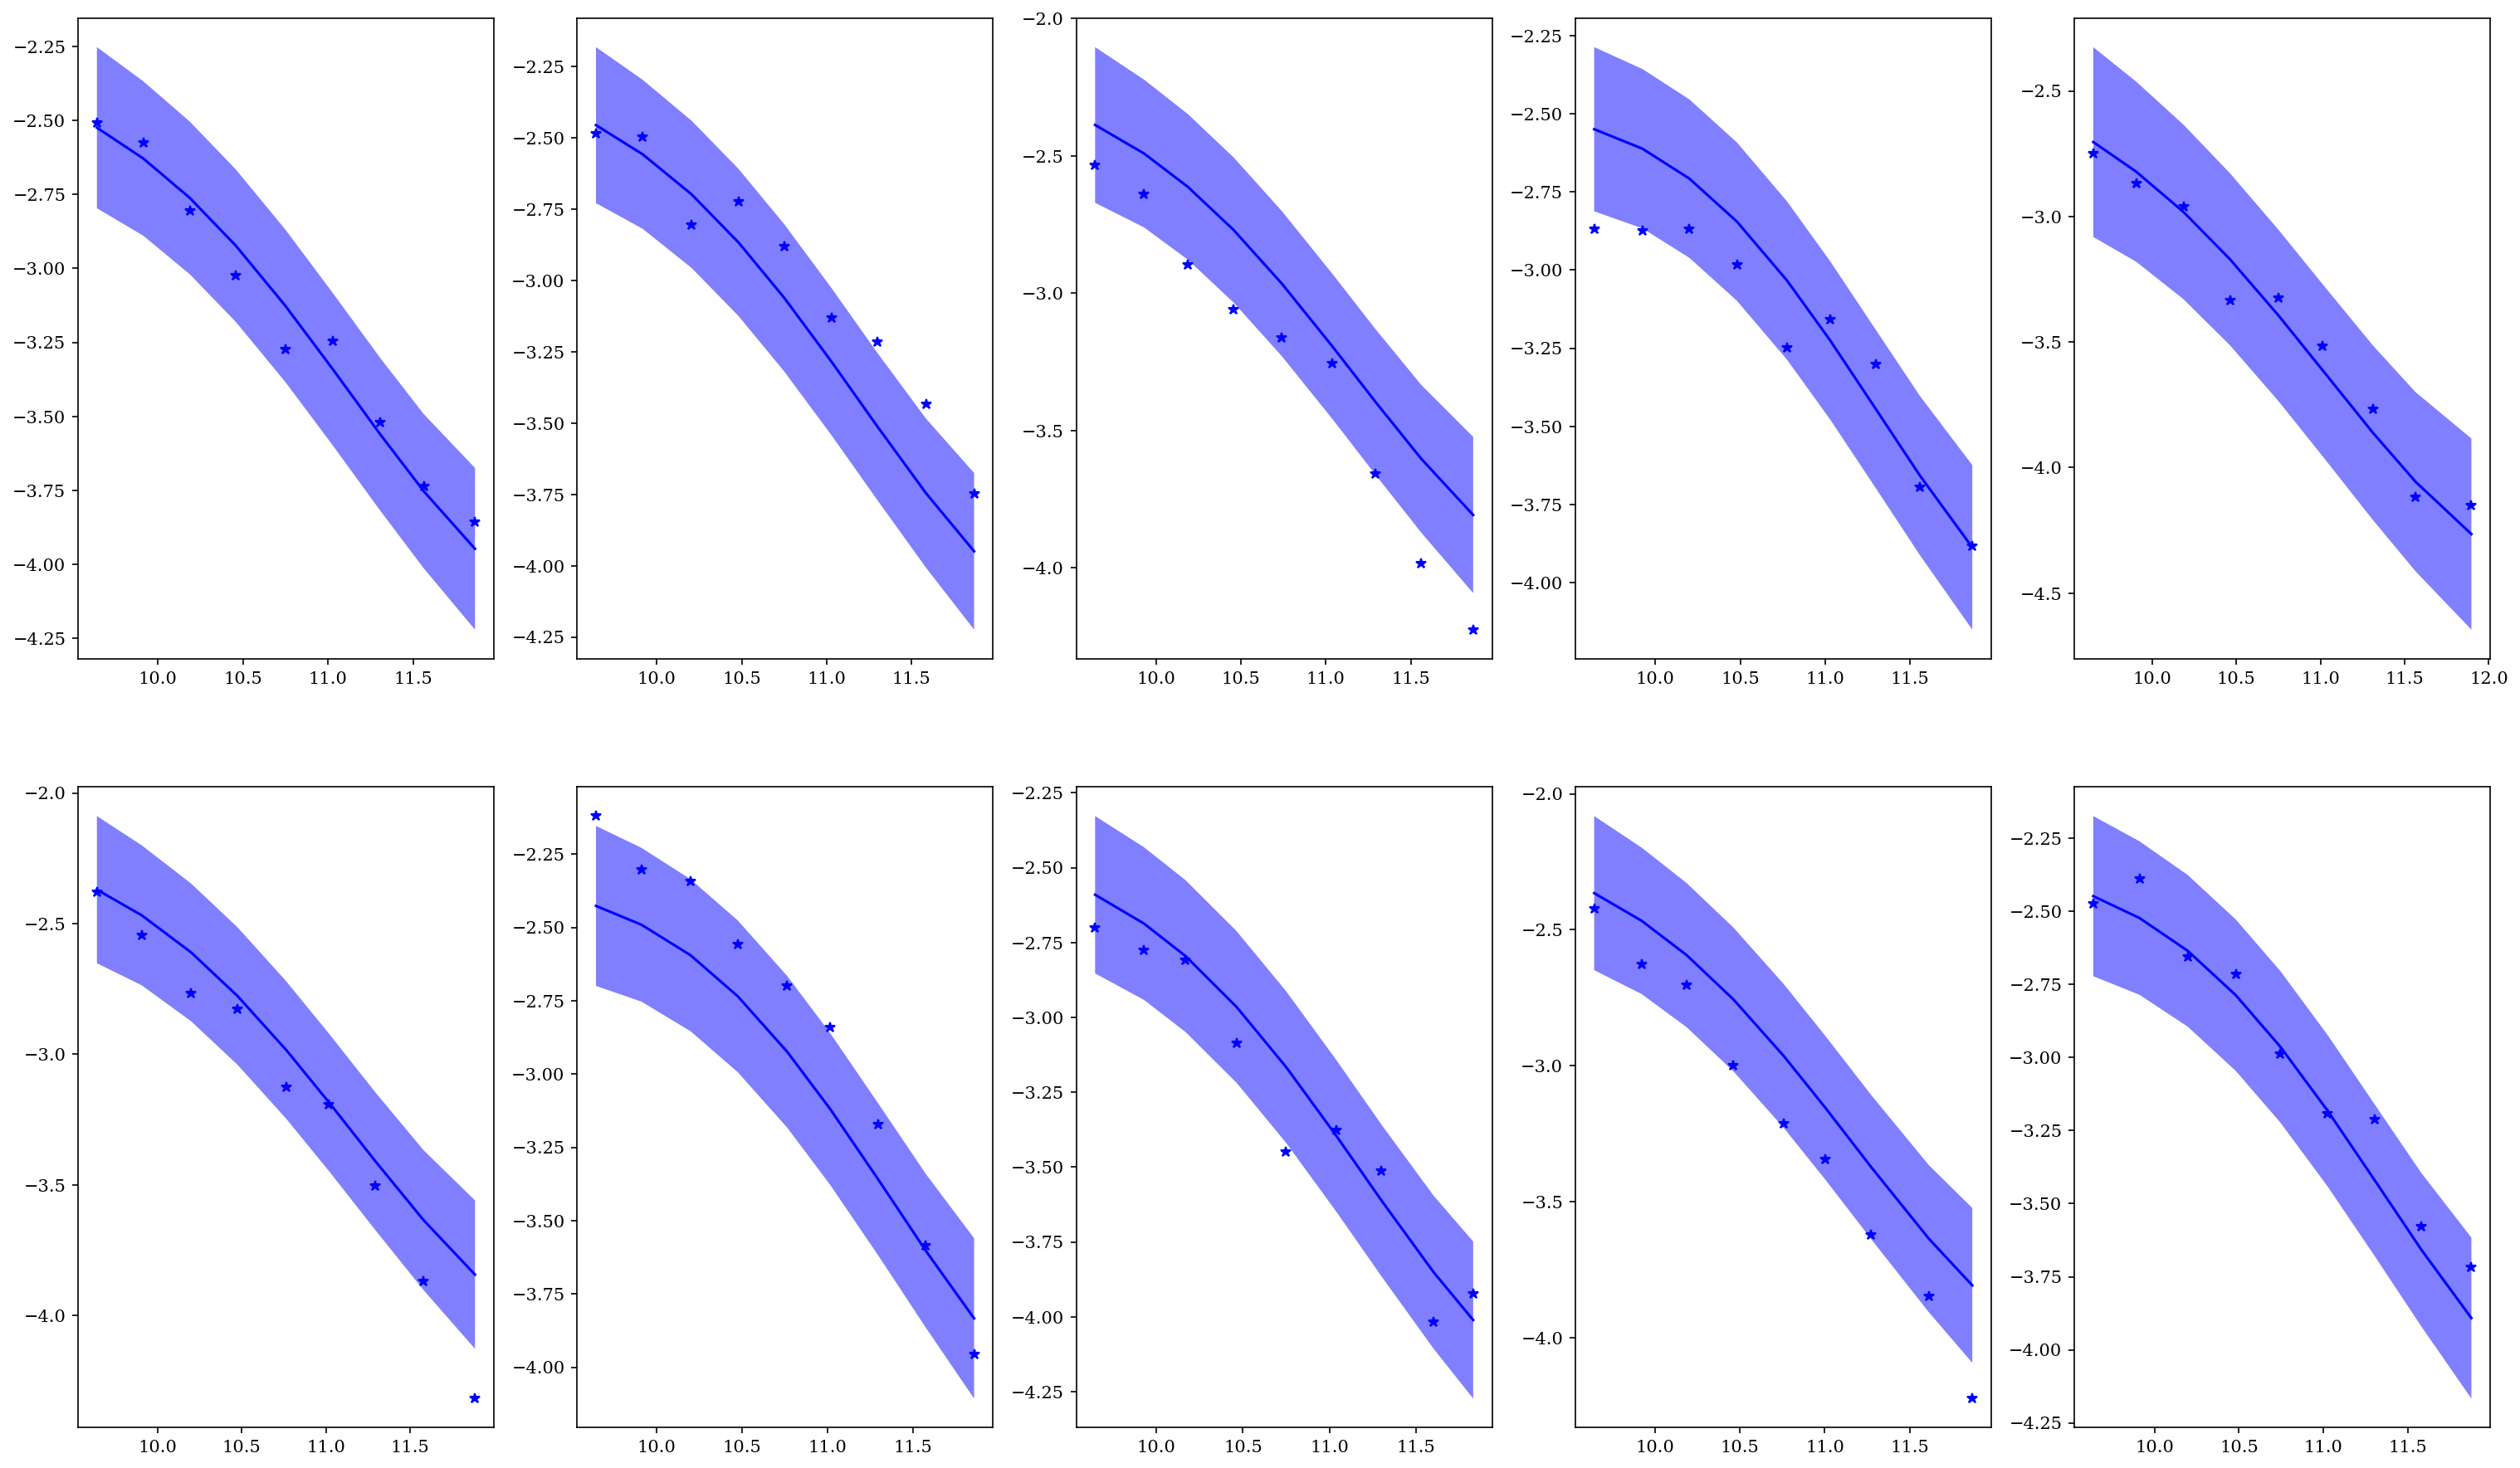

In [386]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(2, 5, figsize=(25, 15), dpi=150)

    for i in range(2):
        for j in range(5):
    
            test_x = torch.asarray(pars(test_sel[5*i+j], np.log10(zoom_smf[name_list[test_sel[5*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood(model(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot test data as black stars
            ax[i,j].plot(np.log10(zoom_smf[name_list[test_sel[5*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[test_sel[5*i+j]]]['smf'][0]), 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


/tmp/ipykernel_431096/1663485653.py:20: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - observed_pred2.mean.numpy(), color='r', lw=0.7)
/tmp/ipykernel_431096/1663485653.py:21: RuntimeWarning: divide by zero encountered in log10
  ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()-observed_pred2.stddev.numpy()) , np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='r', edgecolor=None)


Text(0.5, 1.0, 'Validation Data [41-100]')

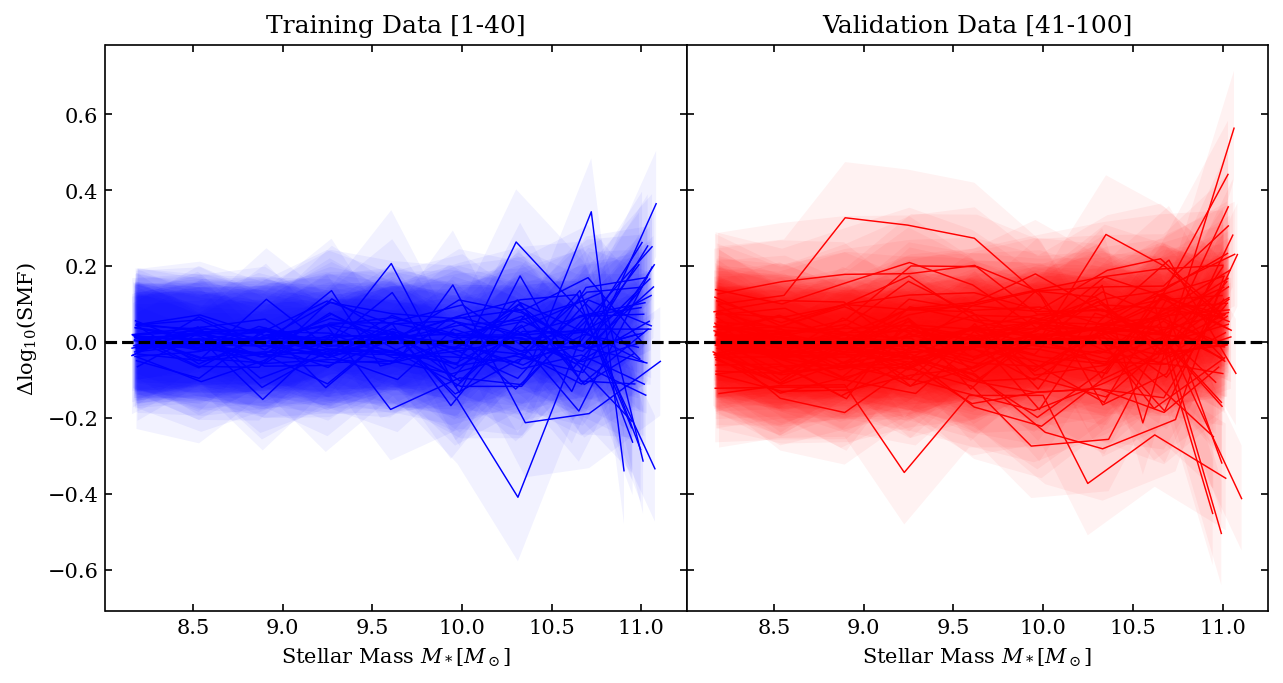

In [455]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    for i in range(40):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  np.log10(smf[train_sel[i]]['smf'][:-5]) - observed_pred1.mean.numpy(), color='b', lw=0.7)
        ax[0].fill_between(np.log10(smf[train_sel[i]]['mstar'][:-5]), np.log10(smf[train_sel[i]]['smf'][:-5]) - (observed_pred1.mean.numpy()-observed_pred1.stddev.numpy()) , np.log10(smf[train_sel[i]]['smf'][:-5]) - (observed_pred1.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='b', edgecolor=None)

    for i in range(60):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - observed_pred2.mean.numpy(), color='r', lw=0.7)
        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()-observed_pred2.stddev.numpy()) , np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='r', edgecolor=None)
#        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - lower2.numpy(), np.log10(smf[test_sel[i]]['smf'][:-5]) - upper2.numpy(), alpha=0.01, color='r', edgecolor=None)

    # Plot training data as black stars
    ax[0].axhline(0, color='k', ls='--')
    ax[1].axhline(0, color='k', ls='--')

ax[0].set_ylabel('$\Delta \log_{10}(\\mathrm{SMF})$')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-40]')
ax[1].set_title('Validation Data [41-100]')

Text(0.5, 1.0, 'Validation Data [41-100]')

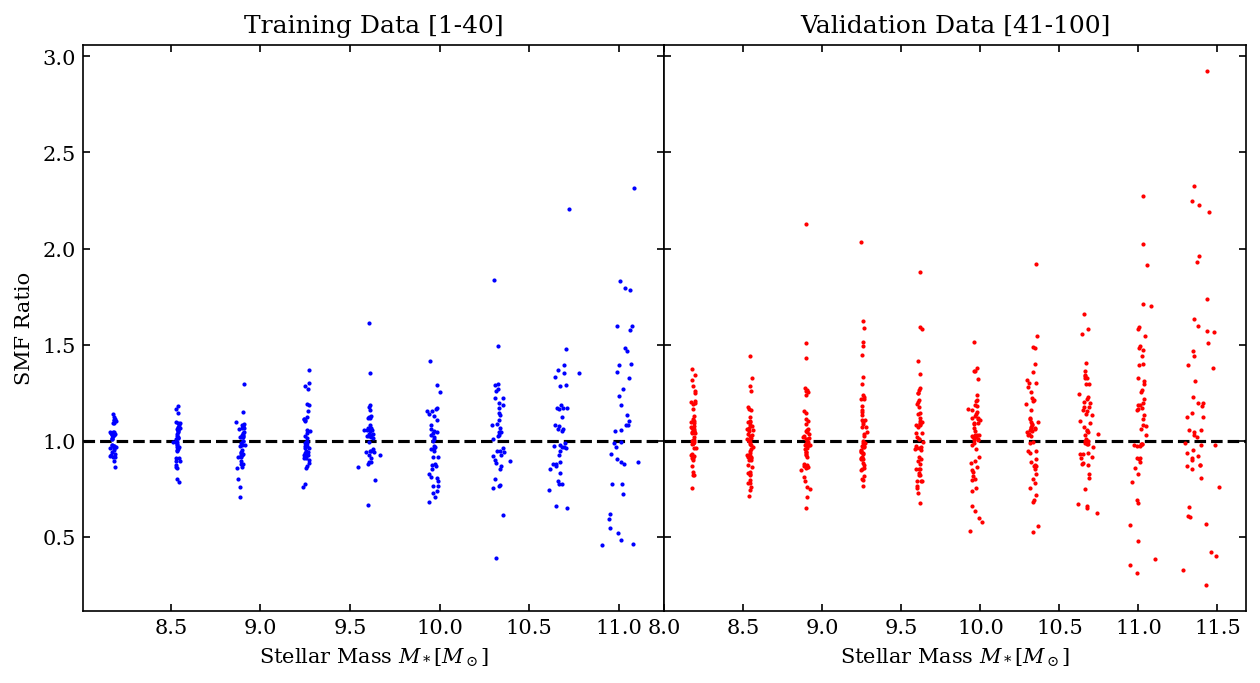

In [426]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax[0].axhline(1, color='k', ls='--')
    ax[1].axhline(1, color='k', ls='--')

    for i in range(40):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
            lower1, upper1 = observed_pred1.confidence_region()
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  smf[train_sel[i]]['smf'][:-5] / 10**observed_pred1.mean.numpy(), color='b', ls='', marker='o', ms=1)

    for i in range(60):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-4])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
            lower2, upper2 = observed_pred2.confidence_region()
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-4]), smf[test_sel[i]]['smf'][:-4] / 10**observed_pred2.mean.numpy(), color='r', ls='', marker='o', ms=1)

ax[0].set_ylabel('SMF Ratio')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-40]')
ax[1].set_title('Validation Data [41-100]')